# Phân tích benchmark Langflow Component Compilation Cache

## 1. Tổng quan thí nghiệm

Notebook so sánh hai thí nghiệm chạy **cùng workload SCRFD face detection**:

- **Experiment A — Baseline:** Langflow/LFX chạy bình thường, chưa có Component Compilation Cache.
- **Experiment B — Compilation Cache:** Langflow/LFX tái sử dụng phần chuẩn bị/biên dịch Component definition khi definition không đổi.

Mục tiêu là đo xem Component Compilation Cache có làm giảm latency của Langflow trong repeated warm-state execution hay không. Cache **không lưu output**, vì vậy mỗi request vẫn nhận input mới, tạo execution riêng, chạy SCRFD inference và sinh output mới.

```text
                 CÙNG WORKLOAD

Baseline                            Compilation Cache

Upload                              Upload
  ↓                                   ↓
Langflow                              Langflow
  ↓                                   ↓
LFX bình thường                       LFX + Compilation Cache
  ↓                                   ↓
SCRFD Flow                            SCRFD Flow
  ↓                                   ↓
Result                               Result
```

### Luồng xử lý chung

```text
User upload image → Chat Input → SCRFD Preprocess → SCRFD Inference
→ SCRFD Draw Detections → Detection Image Output → Chat Output → Result
```

### Phương pháp benchmark

Mỗi phiên bản được restart backend, chạy 5 request warm-up rồi đo 100 request **tuần tự**. Mỗi request gồm upload ảnh mới, lưu file qua API Langflow, chạy toàn bộ flow và nhận response.

Kết quả chính đại diện cho **warm / steady-state repeated execution**. Đây không phải concurrent load test, stress test, maximum-throughput test, GPU benchmark, pure SCRFD inference benchmark hay đánh giá cold-start đầy đủ.

## 2. Cấu hình và thư viện

Chỉ cần chỉnh bốn tên file dưới đây nếu dữ liệu được đổi tên. Không có đường dẫn dữ liệu nào khác bị hard-code trong notebook.

In [1]:
from pathlib import Path
import warnings

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from scipy.stats import mannwhitneyu

# Cấu hình tên bốn file benchmark trong cùng thư mục với notebook
BASELINE_RUNS = "baseline_runs.csv"
BASELINE_SUMMARY = "baseline_summary.csv"
CACHE_RUNS = "compilation_cache_runs.csv"
CACHE_SUMMARY = "compilation_cache_summary.csv"

# Ngưỡng này chỉ dùng để mô tả thay đổi rất nhỏ, không thay thế kiểm định thống kê
NEGLIGIBLE_CHANGE_PCT = 2.0

DATA_DIR = Path.cwd()
generated_figures = []

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

print(f"pandas: {pd.__version__}")
print(f"matplotlib: {matplotlib.__version__}")

pandas: 3.0.5
matplotlib: 3.10.7


## 3. Nạp dữ liệu

Notebook kiểm tra sự tồn tại của từng file trước khi đọc. Dữ liệu raw được giữ riêng; mọi chuyển kiểu và metric dẫn xuất chỉ được tạo trên bản sao dùng cho phân tích.

In [2]:
def load_csv_checked(filename):
    '''Đọc CSV và báo lỗi tiếng Việt nếu file không tồn tại.'''
    path = DATA_DIR / filename
    if not path.is_file():
        raise FileNotFoundError(
            f"Không tìm thấy file '{filename}' trong thư mục '{DATA_DIR}'. "
            "Hãy kiểm tra lại tên file tại cell CONFIG."
        )
    dataframe = pd.read_csv(path)
    print(f"Đã đọc: {filename} — {dataframe.shape[0]} dòng, {dataframe.shape[1]} cột")
    return dataframe


# Đọc và giữ nguyên bốn DataFrame gốc để có thể đối chiếu khi cần
baseline_runs_raw = load_csv_checked(BASELINE_RUNS)
baseline_summary_raw = load_csv_checked(BASELINE_SUMMARY)
cache_runs_raw = load_csv_checked(CACHE_RUNS)
cache_summary_raw = load_csv_checked(CACHE_SUMMARY)

Đã đọc: baseline_runs.csv — 100 dòng, 25 cột
Đã đọc: baseline_summary.csv — 16 dòng, 9 cột
Đã đọc: compilation_cache_runs.csv — 100 dòng, 25 cột
Đã đọc: compilation_cache_summary.csv — 16 dòng, 9 cột


In [3]:
print("\nBaseline — 5 dòng đầu:")
display(baseline_runs_raw.head())
print("Compilation Cache — 5 dòng đầu:")
display(cache_runs_raw.head())

print(f"Kích thước Baseline: {baseline_runs_raw.shape}")
print(f"Kích thước Compilation Cache: {cache_runs_raw.shape}")

for version, dataframe in {
    "Baseline": baseline_runs_raw,
    "Compilation Cache": cache_runs_raw,
}.items():
    if not 90 <= len(dataframe) <= 110:
        warnings.warn(
            f"{version} có {len(dataframe)} request; khác đáng kể so với khoảng 100 request dự kiến.",
            stacklevel=2,
        )


Baseline — 5 dòng đầu:


,run,marker,success,http_status,uploaded_file_path,upload_latency_ms,flow_api_latency_ms,user_e2e_latency_ms,client_between_steps_ms,trace_id,trace_total_latency_ms,chat_input_ms,scrfd_preprocess_ms,scrfd_inference_ms,scrfd_draw_detections_ms,detection_image_output_ms,chat_output_ms,component_sum_ms,internal_orchestration_overhead_ms,internal_orchestration_overhead_percent,flow_api_minus_trace_ms,user_e2e_minus_trace_ms,user_e2e_minus_component_sum_ms,component_match_ok,error
0,1,benchmark-real-upload-001,True,200,d7b1b956-0181-472e-8d6f-ccf7e55a4066/2026-09-1...,14.3890,106.6105,121.0642,0.0648,7cf77553-3087-4276-9305-56698ea90902,45.0,2.0,7.0,20.0,5.0,1.0,2.0,37.0,8.0,17.7778,61.6105,76.0642,84.0642,True,NaN
1,2,benchmark-real-upload-002,True,200,d7b1b956-0181-472e-8d6f-ccf7e55a4066/2026-09-1...,14.8803,114.2990,129.2357,0.0565,866a2a19-ca75-448f-a2ed-3883a86e3e04,44.0,2.0,9.0,18.0,5.0,1.0,2.0,37.0,7.0,15.9091,70.2990,85.2357,92.2357,True,NaN
2,3,benchmark-real-upload-003,True,200,d7b1b956-0181-472e-8d6f-ccf7e55a4066/2026-09-1...,8.9863,94.1328,103.2290,0.1098,db3f49a6-314d-48ab-ad2e-59396d952336,49.0,2.0,9.0,21.0,6.0,1.0,2.0,41.0,8.0,16.3265,45.1328,54.2290,62.2290,True,NaN
3,4,benchmark-real-upload-004,True,200,d7b1b956-0181-472e-8d6f-ccf7e55a4066/2026-09-1...,8.9655,101.4008,110.4262,0.0599,7e75bb0e-f86f-4284-a02f-feef72c9acec,45.0,2.0,8.0,18.0,5.0,2.0,2.0,37.0,8.0,17.7778,56.4008,65.4262,73.4262,True,NaN
4,5,benchmark-real-upload-005,True,200,d7b1b956-0181-472e-8d6f-ccf7e55a4066/2026-09-1...,8.9811,91.9288,101.0030,0.0931,fcb8cb63-0a6d-4101-bd21-d383fd046e3e,42.0,3.0,6.0,17.0,6.0,0.0,2.0,34.0,8.0,19.0476,49.9288,59.0030,67.0030,True,NaN


Compilation Cache — 5 dòng đầu:


,run,marker,success,http_status,uploaded_file_path,upload_latency_ms,flow_api_latency_ms,user_e2e_latency_ms,client_between_steps_ms,trace_id,trace_total_latency_ms,chat_input_ms,scrfd_preprocess_ms,scrfd_inference_ms,scrfd_draw_detections_ms,detection_image_output_ms,chat_output_ms,component_sum_ms,internal_orchestration_overhead_ms,internal_orchestration_overhead_percent,flow_api_minus_trace_ms,user_e2e_minus_trace_ms,user_e2e_minus_component_sum_ms,component_match_ok,error
0,1,benchmark-real-upload-001,True,200,d7b1b956-0181-472e-8d6f-ccf7e55a4066/2026-09-1...,9.7215,91.7815,101.5733,0.0703,6d015581-c2e7-4bab-a5e4-77e00f87169d,50.0,2.0,12.0,20.0,6.0,0.0,1.0,41.0,9.0,18.0000,41.7815,51.5733,60.5733,True,NaN
1,2,benchmark-real-upload-002,True,200,d7b1b956-0181-472e-8d6f-ccf7e55a4066/2026-09-1...,8.7681,101.8990,110.7461,0.0790,3fc2b62d-f53f-4a04-9c2f-4ac2d03021c1,59.0,2.0,15.0,28.0,5.0,0.0,2.0,52.0,7.0,11.8644,42.8990,51.7461,58.7461,True,NaN
2,3,benchmark-real-upload-003,True,200,d7b1b956-0181-472e-8d6f-ccf7e55a4066/2026-09-1...,8.8008,107.0464,115.9135,0.0664,5b8690dc-98d8-4cbd-8c09-fd35e07b65e6,63.0,2.0,17.0,30.0,5.0,0.0,2.0,56.0,7.0,11.1111,44.0464,52.9135,59.9135,True,NaN
3,4,benchmark-real-upload-004,True,200,d7b1b956-0181-472e-8d6f-ccf7e55a4066/2026-09-1...,8.3220,409.5439,417.9296,0.0637,c153cbee-0a03-4d79-80f1-aa49c5f83195,53.0,7.0,16.0,16.0,5.0,0.0,2.0,46.0,7.0,13.2075,356.5439,364.9296,371.9296,True,NaN
4,5,benchmark-real-upload-005,True,200,d7b1b956-0181-472e-8d6f-ccf7e55a4066/2026-09-1...,8.4740,102.9469,111.4907,0.0697,aa10407e-179f-4c51-8d17-ccdc91320a1e,59.0,2.0,11.0,31.0,5.0,0.0,1.0,50.0,9.0,15.2542,43.9469,52.4907,61.4907,True,NaN


Kích thước Baseline: (100, 25)
Kích thước Compilation Cache: (100, 25)


## 4. Kiểm tra chất lượng dữ liệu

Các kiểm tra dưới đây không tự động loại bỏ dòng lỗi. Nếu một phép tính cần số hợp lệ, hàm thống kê chỉ bỏ giá trị thiếu của **metric đang xét** và luôn báo `Count`/`Missing` để phạm vi dữ liệu được minh bạch.

In [4]:
COMPONENT_COLUMNS = [
    "chat_input_ms",
    "scrfd_preprocess_ms",
    "scrfd_inference_ms",
    "scrfd_draw_detections_ms",
    "detection_image_output_ms",
    "chat_output_ms",
]

REQUIRED_COLUMNS = [
    "run",
    "success",
    "http_status",
    "upload_latency_ms",
    "flow_api_latency_ms",
    "user_e2e_latency_ms",
    "trace_id",
    "trace_total_latency_ms",
    *COMPONENT_COLUMNS,
]

NUMERIC_COLUMNS = [
    "run",
    "http_status",
    "upload_latency_ms",
    "flow_api_latency_ms",
    "user_e2e_latency_ms",
    "trace_total_latency_ms",
    *COMPONENT_COLUMNS,
]

COMPONENT_LABELS = {
    "chat_input_ms": "Chat Input",
    "scrfd_preprocess_ms": "SCRFD Preprocess",
    "scrfd_inference_ms": "SCRFD Inference",
    "scrfd_draw_detections_ms": "SCRFD Draw Detections",
    "detection_image_output_ms": "Detection Image Output",
    "chat_output_ms": "Chat Output",
}

CORE_METRICS = {
    "Upload": "upload_latency_ms",
    "Flow API": "flow_api_latency_ms",
    "User E2E": "user_e2e_latency_ms",
    "Trace Total": "trace_total_latency_ms",
    "Component Sum": "component_sum_ms",
    "Internal Orchestration": "langflow_orchestration_overhead_ms",
    "Outside Trace": "outside_trace_gap_ms",
}

In [5]:
def validate_required_columns(dataframe, version):
    '''Dừng sớm và chỉ rõ các cột bắt buộc đang thiếu.'''
    missing_columns = [column for column in REQUIRED_COLUMNS if column not in dataframe.columns]
    if missing_columns:
        raise ValueError(
            f"Dữ liệu {version} thiếu cột bắt buộc: {', '.join(missing_columns)}. "
            "Hãy kiểm tra schema của file runs.csv."
        )


def prepare_analysis_data(raw_dataframe, version):
    '''Tạo bản sao phân tích và tính lại metric từ dữ liệu raw.'''
    validate_required_columns(raw_dataframe, version)
    dataframe = raw_dataframe.copy(deep=True)

    # Chuyển kiểu trên bản sao; giá trị không hợp lệ thành NaN để được báo trong validation
    for column in NUMERIC_COLUMNS:
        dataframe[column] = pd.to_numeric(dataframe[column], errors="coerce")

    # Chuẩn hóa success nhưng không ghi đè DataFrame raw
    dataframe["success_normalized"] = (
        dataframe["success"].astype(str).str.strip().str.lower().map(
            {"true": True, "1": True, "yes": True, "false": False, "0": False, "no": False}
        )
    )

    # Chỉ tính Component Sum khi đủ toàn bộ span để không che giấu span bị thiếu
    dataframe["component_sum_ms"] = dataframe[COMPONENT_COLUMNS].sum(
        axis=1, min_count=len(COMPONENT_COLUMNS)
    )
    dataframe["langflow_orchestration_overhead_ms"] = (
        dataframe["trace_total_latency_ms"] - dataframe["component_sum_ms"]
    )
    dataframe["outside_trace_gap_ms"] = (
        dataframe["flow_api_latency_ms"] - dataframe["trace_total_latency_ms"]
    )
    return dataframe


baseline_runs = prepare_analysis_data(baseline_runs_raw, "Baseline")
cache_runs = prepare_analysis_data(cache_runs_raw, "Compilation Cache")

In [6]:
def build_validation_row(dataframe):
    '''Tổng hợp các dấu hiệu chất lượng dữ liệu cần báo cáo.'''
    successful = (
        dataframe["success_normalized"].eq(True)
        & dataframe["http_status"].between(200, 299, inclusive="both")
    )
    missing_components = dataframe[COMPONENT_COLUMNS].isna().any(axis=1)
    return {
        "Total runs": len(dataframe),
        "Successful": int(successful.sum()),
        "Failed": int((~successful).sum()),
        "HTTP errors": int((~dataframe["http_status"].between(200, 299, inclusive="both")).sum()),
        "Duplicate run IDs": int(dataframe["run"].duplicated(keep=False).sum()),
        "Missing trace": int(
            (dataframe["trace_id"].isna() | dataframe["trace_total_latency_ms"].isna()).sum()
        ),
        "Missing component spans": int(missing_components.sum()),
        "Negative overhead": int(
            dataframe["langflow_orchestration_overhead_ms"].lt(0).sum()
        ),
        "Invalid success values": int(dataframe["success_normalized"].isna().sum()),
    }


validation_table = pd.DataFrame(
    {
        "Baseline": build_validation_row(baseline_runs),
        "Compilation Cache": build_validation_row(cache_runs),
    }
)
validation_table.index.name = "Check"
display(validation_table)

,Baseline,Compilation Cache
Check,,
Total runs,100,100
Successful,100,100
Failed,0,0
HTTP errors,0,0
Duplicate run IDs,0,0
Missing trace,0,0
Missing component spans,0,0
Negative overhead,0,0
Invalid success values,0,0


In [7]:
# Báo cáo chi tiết missing value và lỗi chuyển kiểu thay vì âm thầm bỏ qua
missing_values_table = pd.DataFrame(
    {
        "Baseline": baseline_runs.isna().sum(),
        "Compilation Cache": cache_runs.isna().sum(),
    }
)
missing_values_table = missing_values_table.loc[
    missing_values_table.sum(axis=1).gt(0)
]

numeric_quality_rows = []
for column in NUMERIC_COLUMNS:
    numeric_quality_rows.append(
        {
            "Cột": column,
            "Baseline không phải số": int(baseline_runs[column].isna().sum()),
            "Cache không phải số": int(cache_runs[column].isna().sum()),
            "Kiểu Baseline": str(baseline_runs[column].dtype),
            "Kiểu Cache": str(cache_runs[column].dtype),
        }
    )
numeric_quality_table = pd.DataFrame(numeric_quality_rows)

print("Các cột có giá trị thiếu:")
display(missing_values_table if not missing_values_table.empty else Markdown("Không phát hiện giá trị thiếu."))
print("Kiểm tra kiểu dữ liệu metric:")
display(numeric_quality_table)

Các cột có giá trị thiếu:


,Baseline,Compilation Cache
error,100,100


Kiểm tra kiểu dữ liệu metric:


,Cột,Baseline không phải số,Cache không phải số,Kiểu Baseline,Kiểu Cache
0,run,0,0,int64,int64
1,http_status,0,0,int64,int64
2,upload_latency_ms,0,0,float64,float64
3,flow_api_latency_ms,0,0,float64,float64
4,user_e2e_latency_ms,0,0,float64,float64
5,trace_total_latency_ms,0,0,float64,float64
6,chat_input_ms,0,0,float64,float64
7,scrfd_preprocess_ms,0,0,float64,float64
8,scrfd_inference_ms,0,0,float64,float64
9,scrfd_draw_detections_ms,0,0,float64,float64


## 5. Metric dẫn xuất

Notebook tự tính lại ba metric sau từ raw spans:

- `component_sum_ms`: tổng sáu Component spans của flow tuần tự.
- `langflow_orchestration_overhead_ms`: `Trace Total - Component Sum`, được gọi là **Langflow Internal Orchestration / Framework Gap**; không được hiểu là toàn bộ overhead so với pure Python.
- `outside_trace_gap_ms`: `Flow API - Trace Total`, biểu diễn phần API/backend nằm ngoài native trace; không tự động được gọi là orchestration overhead.

Dữ liệu trong `summary.csv` chỉ được dùng để đối chiếu, không phải nguồn tính toán chính.

In [8]:
derived_preview_columns = [
    "run",
    "trace_total_latency_ms",
    *COMPONENT_COLUMNS,
    "component_sum_ms",
    "langflow_orchestration_overhead_ms",
    "flow_api_latency_ms",
    "outside_trace_gap_ms",
]
display(baseline_runs[derived_preview_columns].head())
display(cache_runs[derived_preview_columns].head())

,run,trace_total_latency_ms,chat_input_ms,scrfd_preprocess_ms,scrfd_inference_ms,scrfd_draw_detections_ms,detection_image_output_ms,chat_output_ms,component_sum_ms,langflow_orchestration_overhead_ms,flow_api_latency_ms,outside_trace_gap_ms
0,1,45.0,2.0,7.0,20.0,5.0,1.0,2.0,37.0,8.0,106.6105,61.6105
1,2,44.0,2.0,9.0,18.0,5.0,1.0,2.0,37.0,7.0,114.2990,70.2990
2,3,49.0,2.0,9.0,21.0,6.0,1.0,2.0,41.0,8.0,94.1328,45.1328
3,4,45.0,2.0,8.0,18.0,5.0,2.0,2.0,37.0,8.0,101.4008,56.4008
4,5,42.0,3.0,6.0,17.0,6.0,0.0,2.0,34.0,8.0,91.9288,49.9288


,run,trace_total_latency_ms,chat_input_ms,scrfd_preprocess_ms,scrfd_inference_ms,scrfd_draw_detections_ms,detection_image_output_ms,chat_output_ms,component_sum_ms,langflow_orchestration_overhead_ms,flow_api_latency_ms,outside_trace_gap_ms
0,1,50.0,2.0,12.0,20.0,6.0,0.0,1.0,41.0,9.0,91.7815,41.7815
1,2,59.0,2.0,15.0,28.0,5.0,0.0,2.0,52.0,7.0,101.8990,42.8990
2,3,63.0,2.0,17.0,30.0,5.0,0.0,2.0,56.0,7.0,107.0464,44.0464
3,4,53.0,7.0,16.0,16.0,5.0,0.0,2.0,46.0,7.0,409.5439,356.5439
4,5,59.0,2.0,11.0,31.0,5.0,0.0,1.0,50.0,9.0,102.9469,43.9469


## 6. Thống kê mô tả

Mean, P50, P95, min, max và standard deviation được tính lại trực tiếp từ `runs.csv`. `Count` và `Missing` cho biết chính xác số giá trị tham gia từng phép tính.

In [9]:
def summarize_metrics(dataframe, metric_mapping):
    '''Tính thống kê mô tả cho từng metric, không sửa dữ liệu đầu vào.'''
    rows = []
    for label, column in metric_mapping.items():
        values = pd.to_numeric(dataframe[column], errors="coerce")
        valid_values = values.dropna()
        rows.append(
            {
                "Metric": label,
                "Column": column,
                "Count": int(valid_values.count()),
                "Missing": int(values.isna().sum()),
                "Mean": valid_values.mean(),
                "P50": valid_values.quantile(0.50),
                "P95": valid_values.quantile(0.95),
                "Min": valid_values.min(),
                "Max": valid_values.max(),
                "Std": valid_values.std(ddof=1),
            }
        )
    return pd.DataFrame(rows)


baseline_statistics = summarize_metrics(baseline_runs, CORE_METRICS)
cache_statistics = summarize_metrics(cache_runs, CORE_METRICS)

print("Baseline:")
display(baseline_statistics.style.format(precision=2, na_rep="Không đủ dữ liệu"))
print("Compilation Cache:")
display(cache_statistics.style.format(precision=2, na_rep="Không đủ dữ liệu"))

Baseline:


,Metric,Column,Count,Missing,Mean,P50,P95,Min,Max,Std
0,Upload,upload_latency_ms,100,0,12.22,10.46,22.89,8.20,56.92,6.44
1,Flow API,flow_api_latency_ms,100,0,108.17,96.58,160.18,84.09,506.19,45.95
2,User E2E,user_e2e_latency_ms,100,0,120.56,109.00,172.47,92.64,518.32,47.63
3,Trace Total,trace_total_latency_ms,100,0,53.04,48.00,82.00,41.00,131.00,15.02
4,Component Sum,component_sum_ms,100,0,44.50,40.00,68.15,33.00,121.00,13.75
5,Internal Orchestration,langflow_orchestration_overhead_ms,100,0,8.54,8.00,12.00,6.00,23.00,2.00
6,Outside Trace,outside_trace_gap_ms,100,0,55.13,47.41,72.52,41.91,459.19,42.41


Compilation Cache:


,Metric,Column,Count,Missing,Mean,P50,P95,Min,Max,Std
0,Upload,upload_latency_ms,100,0,9.03,8.84,10.33,7.75,12.67,0.73
1,Flow API,flow_api_latency_ms,100,0,111.21,103.11,119.90,91.78,413.53,44.40
2,User E2E,user_e2e_latency_ms,100,0,120.32,112.78,128.75,101.57,423.01,44.39
3,Trace Total,trace_total_latency_ms,100,0,59.23,59.00,66.20,47.00,132.00,8.55
4,Component Sum,component_sum_ms,100,0,51.00,50.00,57.25,39.00,125.00,8.68
5,Internal Orchestration,langflow_orchestration_overhead_ms,100,0,8.23,8.00,11.00,6.00,13.00,1.26
6,Outside Trace,outside_trace_gap_ms,100,0,51.98,44.05,55.87,41.74,365.53,45.09


In [10]:
def compare_with_supplied_summary(computed_statistics, supplied_summary, version):
    '''Đối chiếu số liệu tự tính với summary được cung cấp.'''
    supplied = supplied_summary.copy()
    supplied["metric"] = supplied["metric"].replace(
        {
            "internal_orchestration_overhead_ms": "langflow_orchestration_overhead_ms",
            "flow_api_minus_trace_ms": "outside_trace_gap_ms",
        }
    )
    computed = computed_statistics.rename(
        columns={"Column": "metric", "Mean": "computed_mean", "P50": "computed_p50", "P95": "computed_p95"}
    )[["metric", "computed_mean", "computed_p50", "computed_p95"]]
    available = supplied[[column for column in ["metric", "mean", "p50", "p95"] if column in supplied.columns]].copy()
    for column in ["mean", "p50", "p95"]:
        if column in available.columns:
            available[column] = pd.to_numeric(available[column], errors="coerce")
    comparison = computed.merge(available, on="metric", how="left")
    for statistic in ["mean", "p50", "p95"]:
        if statistic in comparison.columns:
            comparison[f"delta_{statistic}"] = comparison[f"computed_{statistic}"] - comparison[statistic]
    comparison.insert(0, "Version", version)
    return comparison


summary_crosscheck = pd.concat(
    [
        compare_with_supplied_summary(baseline_statistics, baseline_summary_raw, "Baseline"),
        compare_with_supplied_summary(cache_statistics, cache_summary_raw, "Compilation Cache"),
    ],
    ignore_index=True,
)
display(summary_crosscheck.style.format(precision=4, na_rep="Không có trong summary"))

,Version,metric,computed_mean,computed_p50,computed_p95,mean,p50,p95,delta_mean,delta_p50,delta_p95
0,Baseline,upload_latency_ms,12.2244,10.4577,22.8864,12.2244,10.4577,22.8864,-0.0000,-0.0000,0.0000
1,Baseline,flow_api_latency_ms,108.1692,96.5807,160.1763,108.1692,96.5807,160.1763,0.0000,0.0000,0.0000
2,Baseline,user_e2e_latency_ms,120.5554,108.9995,172.4744,120.5554,108.9995,172.4743,-0.0000,0.0001,0.0001
3,Baseline,trace_total_latency_ms,53.0400,48.0000,82.0000,53.0400,48.0000,82.0000,0.0000,0.0000,0.0000
4,Baseline,component_sum_ms,44.5000,40.0000,68.1500,44.5000,40.0000,68.1500,0.0000,0.0000,-0.0000
5,Baseline,langflow_orchestration_overhead_ms,8.5400,8.0000,12.0000,8.5400,8.0000,12.0000,0.0000,0.0000,0.0000
6,Baseline,outside_trace_gap_ms,55.1292,47.4067,72.5153,55.1292,47.4066,72.5152,0.0000,0.0001,0.0001
7,Compilation Cache,upload_latency_ms,9.0288,8.8445,10.3301,9.0288,8.8445,10.3300,-0.0000,0.0000,0.0001
8,Compilation Cache,flow_api_latency_ms,111.2063,103.1119,119.9041,111.2063,103.1119,119.9041,0.0000,-0.0001,-0.0000
9,Compilation Cache,user_e2e_latency_ms,120.3152,112.7829,128.7534,120.3152,112.7829,128.7535,0.0000,0.0000,-0.0001


## 7. So sánh các metric cốt lõi

`Delta ms = Baseline - Compilation Cache`. `Improvement %` dương nghĩa là cache nhanh hơn; giá trị âm được gọi là **regression**, không được gọi là improvement.

In [11]:
def safe_improvement(baseline_value, cache_value):
    '''Tính tỷ lệ nhanh hơn; trả NaN khi baseline bằng 0 hoặc thiếu dữ liệu.'''
    if pd.isna(baseline_value) or pd.isna(cache_value) or baseline_value == 0:
        return np.nan
    return (baseline_value - cache_value) / baseline_value * 100


def build_core_summary(baseline_dataframe, cache_dataframe):
    '''Tạo bảng so sánh mean, P50 và P95 cho metric cốt lõi.'''
    rows = []
    for label, column in CORE_METRICS.items():
        baseline_values = baseline_dataframe[column].dropna()
        cache_values = cache_dataframe[column].dropna()
        baseline_mean = baseline_values.mean()
        cache_mean = cache_values.mean()
        rows.append(
            {
                "Metric": label,
                "Baseline Mean": baseline_mean,
                "Cache Mean": cache_mean,
                "Delta ms": baseline_mean - cache_mean,
                "Improvement %": safe_improvement(baseline_mean, cache_mean),
                "Baseline P50": baseline_values.quantile(0.50),
                "Cache P50": cache_values.quantile(0.50),
                "Baseline P95": baseline_values.quantile(0.95),
                "Cache P95": cache_values.quantile(0.95),
            }
        )
    return pd.DataFrame(rows)


core_summary = build_core_summary(baseline_runs, cache_runs)
display(
    core_summary.style.format(
        {
            "Baseline Mean": "{:.2f}",
            "Cache Mean": "{:.2f}",
            "Delta ms": "{:.2f}",
            "Improvement %": "{:.2f}%",
            "Baseline P50": "{:.2f}",
            "Cache P50": "{:.2f}",
            "Baseline P95": "{:.2f}",
            "Cache P95": "{:.2f}",
        },
        na_rep="Không đủ dữ liệu",
    )
)

,Metric,Baseline Mean,Cache Mean,Delta ms,Improvement %,Baseline P50,Cache P50,Baseline P95,Cache P95
0,Upload,12.22,9.03,3.20,26.14%,10.46,8.84,22.89,10.33
1,Flow API,108.17,111.21,-3.04,-2.81%,96.58,103.11,160.18,119.90
2,User E2E,120.56,120.32,0.24,0.20%,109.00,112.78,172.47,128.75
3,Trace Total,53.04,59.23,-6.19,-11.67%,48.00,59.00,82.00,66.20
4,Component Sum,44.50,51.00,-6.50,-14.61%,40.00,50.00,68.15,57.25
5,Internal Orchestration,8.54,8.23,0.31,3.63%,8.00,8.00,12.00,11.00
6,Outside Trace,55.13,51.98,3.15,5.72%,47.41,44.05,72.52,55.87


## 8. So sánh theo component

Phần này tách rõ thời gian **SCRFD inference compute** khỏi chi phí chuẩn bị/điều phối component của Langflow/LFX. Nếu inference gần như không đổi, đó là hành vi hợp lý vì compilation cache không tối ưu ONNX model compute.

In [12]:
def build_component_comparison(baseline_dataframe, cache_dataframe):
    '''So sánh mean, P50 và P95 của từng component span.'''
    rows = []
    for column, label in COMPONENT_LABELS.items():
        baseline_values = baseline_dataframe[column].dropna()
        cache_values = cache_dataframe[column].dropna()
        baseline_mean = baseline_values.mean()
        cache_mean = cache_values.mean()
        rows.append(
            {
                "Component": label,
                "Baseline Mean": baseline_mean,
                "Cache Mean": cache_mean,
                "Delta ms": baseline_mean - cache_mean,
                "Improvement %": safe_improvement(baseline_mean, cache_mean),
                "Baseline P50": baseline_values.quantile(0.50),
                "Cache P50": cache_values.quantile(0.50),
                "Baseline P95": baseline_values.quantile(0.95),
                "Cache P95": cache_values.quantile(0.95),
            }
        )
    return pd.DataFrame(rows)


component_comparison = build_component_comparison(baseline_runs, cache_runs)
display(component_comparison.style.format(precision=2, na_rep="Không đủ dữ liệu"))

inference_change = component_comparison.loc[
    component_comparison["Component"].eq("SCRFD Inference"), "Improvement %"
].iloc[0]
if abs(inference_change) <= NEGLIGIBLE_CHANGE_PCT:
    display(
        Markdown(
            "**Diễn giải:** SCRFD Inference thay đổi rất nhỏ. Điều này phù hợp với phạm vi "
            "optimization vì Component Compilation Cache tác động vào LFX execution framework, "
            "không tối ưu ONNX inference compute."
        )
    )
else:
    display(
        Markdown(
            f"**Diễn giải:** SCRFD Inference thay đổi {inference_change:.2f}%. "
            "Compilation Cache không trực tiếp tối ưu ONNX compute, nên cần xem đây là biến động "
            "của workload/runtime thay vì tự động quy nguyên nhân cho cache."
        )
    )

,Component,Baseline Mean,Cache Mean,Delta ms,Improvement %,Baseline P50,Cache P50,Baseline P95,Cache P95
0,Chat Input,3.03,2.90,0.13,4.29,3.00,2.00,5.05,3.05
1,SCRFD Preprocess,10.57,12.33,-1.76,-16.65,9.00,12.00,16.05,18.00
2,SCRFD Inference,22.89,28.43,-5.54,-24.20,19.00,29.00,37.00,33.00
3,SCRFD Draw Detections,5.48,5.15,0.33,6.02,5.00,5.00,7.00,6.00
4,Detection Image Output,0.59,0.18,0.41,69.49,1.00,0.00,1.05,1.00
5,Chat Output,1.94,2.01,-0.07,-3.61,2.00,2.00,2.05,2.00


**Diễn giải:** SCRFD Inference thay đổi -24.20%. Compilation Cache không trực tiếp tối ưu ONNX compute, nên cần xem đây là biến động của workload/runtime thay vì tự động quy nguyên nhân cho cache.

## 9. Trực quan hóa Mean, P50 và P95

Mỗi biểu đồ là một figure độc lập, có đơn vị ms, nhãn tiếng Việt và grid nhẹ.

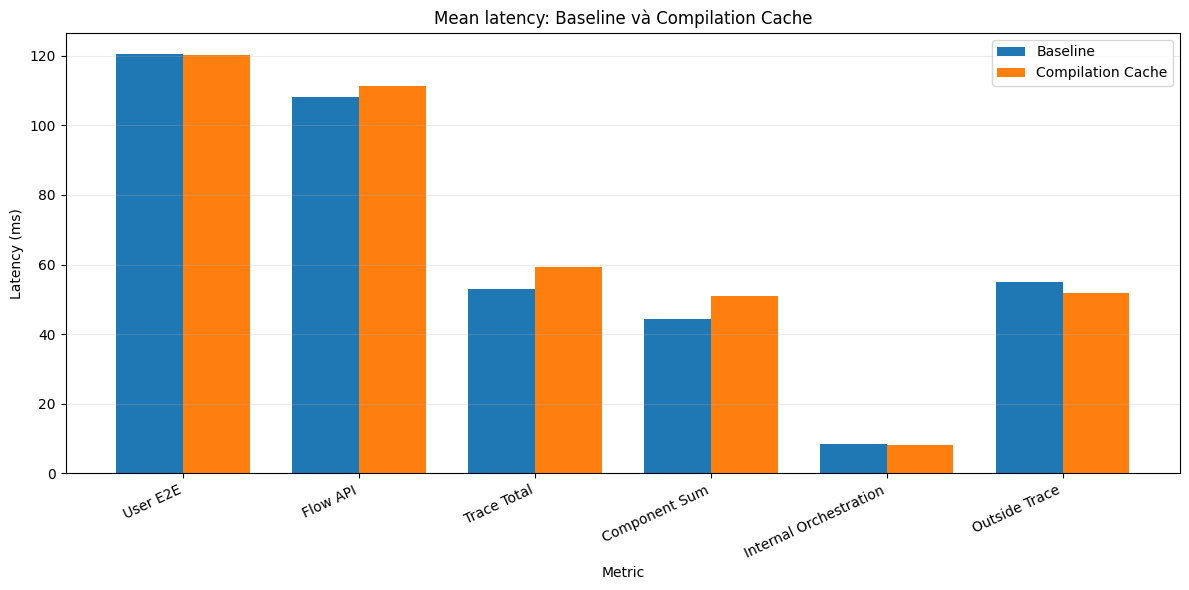

In [13]:
PLOT_METRICS = [
    "User E2E",
    "Flow API",
    "Trace Total",
    "Component Sum",
    "Internal Orchestration",
    "Outside Trace",
]


def grouped_bar_from_summary(value_baseline, value_cache, title):
    '''Vẽ grouped bar cho một statistic từ bảng core summary.'''
    plot_data = core_summary.set_index("Metric").loc[PLOT_METRICS]
    positions = np.arange(len(plot_data))
    width = 0.38
    fig, axis = plt.subplots(figsize=(12, 6))
    axis.bar(positions - width / 2, plot_data[value_baseline], width, label="Baseline")
    axis.bar(positions + width / 2, plot_data[value_cache], width, label="Compilation Cache")
    axis.set_xticks(positions, plot_data.index, rotation=25, ha="right")
    axis.set_ylabel("Latency (ms)")
    axis.set_xlabel("Metric")
    axis.set_title(title)
    axis.legend()
    axis.grid(axis="y", alpha=0.25)
    fig.tight_layout()
    generated_figures.append(fig)
    plt.show()
    return fig


# Biểu đồ 1: latency trung bình trước và sau cache
mean_latency_figure = grouped_bar_from_summary(
    "Baseline Mean", "Cache Mean", "Mean latency: Baseline và Compilation Cache"
)

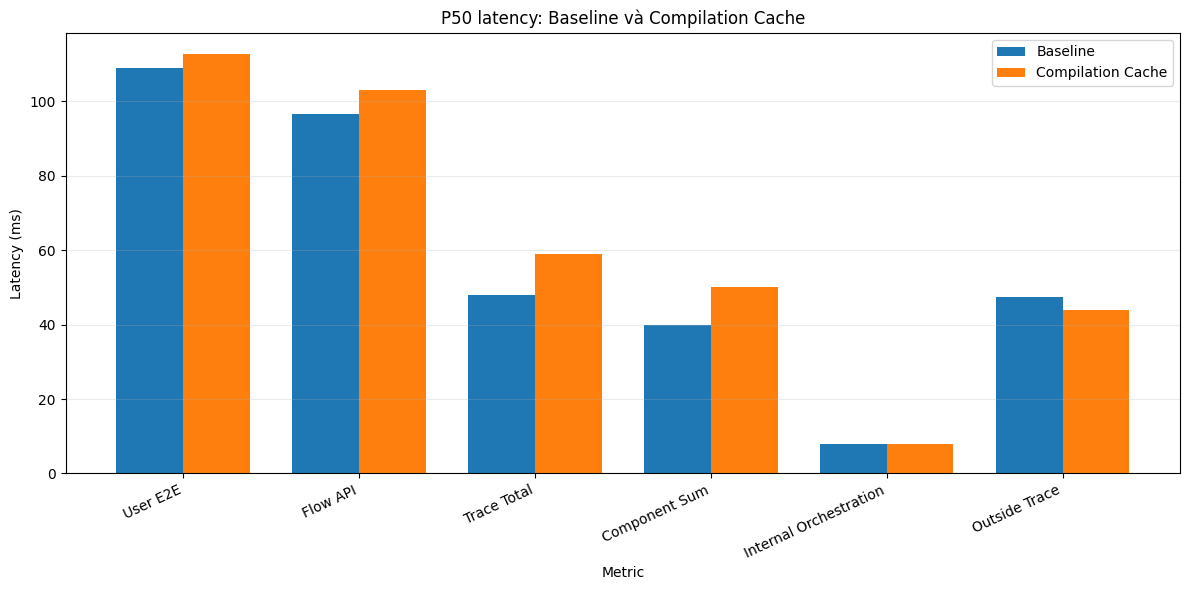

In [14]:
# Biểu đồ 2: P50 đại diện cho request điển hình
p50_latency_figure = grouped_bar_from_summary(
    "Baseline P50", "Cache P50", "P50 latency: Baseline và Compilation Cache"
)

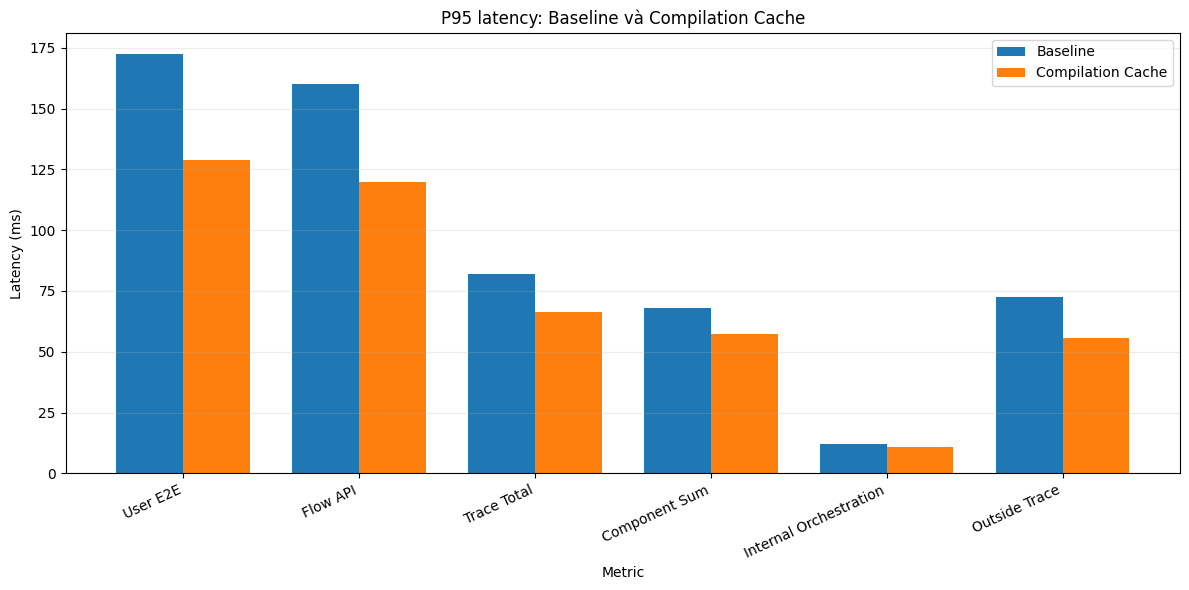

In [15]:
# Biểu đồ 3: P95 dùng để quan sát tail latency
p95_latency_figure = grouped_bar_from_summary(
    "Baseline P95", "Cache P95", "P95 latency: Baseline và Compilation Cache"
)

## 10. Trực quan hóa theo component và theo request

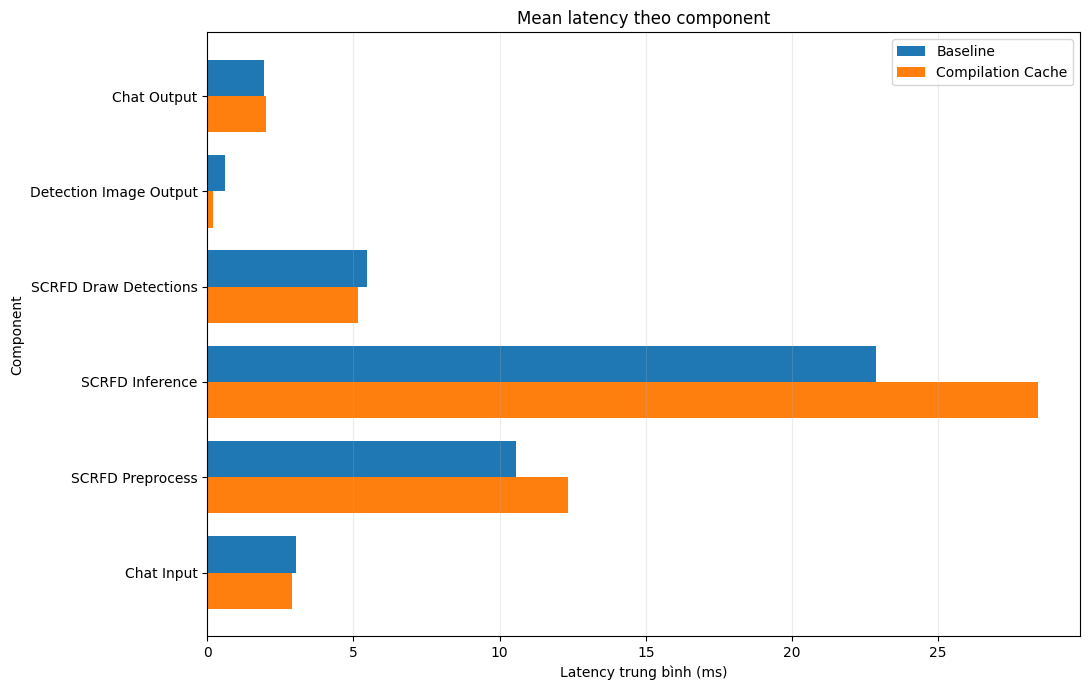

In [16]:
# Biểu đồ 4: mean latency của từng component
component_plot = component_comparison.set_index("Component")
positions = np.arange(len(component_plot))
height = 0.38
fig, axis = plt.subplots(figsize=(11, 7))
axis.barh(positions + height / 2, component_plot["Baseline Mean"], height, label="Baseline")
axis.barh(positions - height / 2, component_plot["Cache Mean"], height, label="Compilation Cache")
axis.set_yticks(positions, component_plot.index)
axis.set_xlabel("Latency trung bình (ms)")
axis.set_ylabel("Component")
axis.set_title("Mean latency theo component")
axis.legend()
axis.grid(axis="x", alpha=0.25)
fig.tight_layout()
generated_figures.append(fig)
component_mean_figure = fig
plt.show()

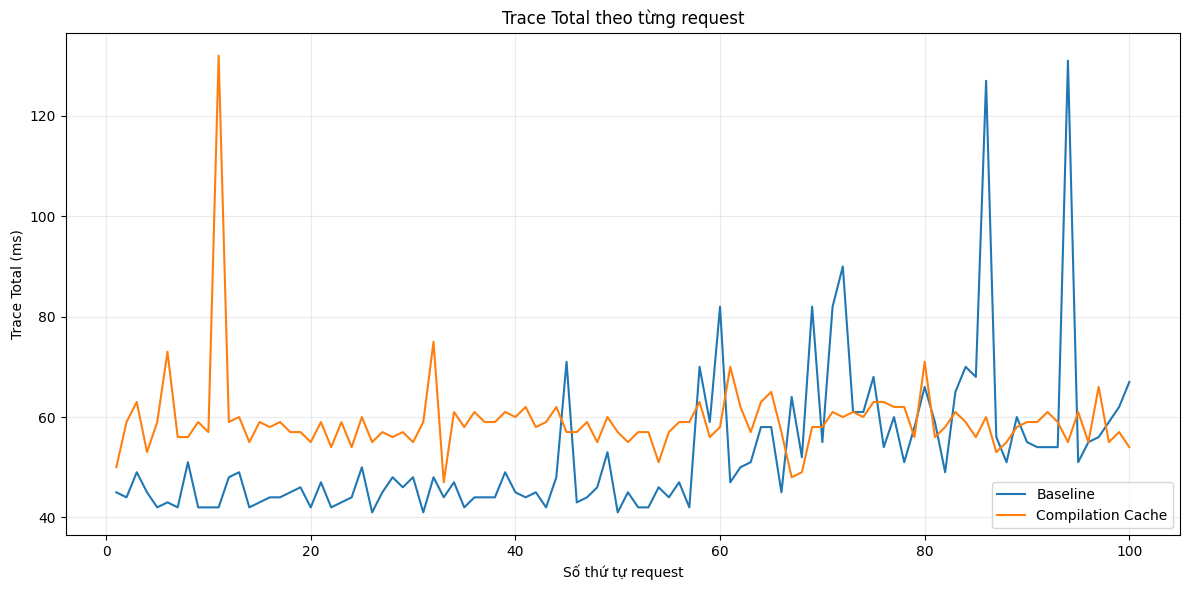

In [17]:
# Biểu đồ 5: Trace Total theo thứ tự request để quan sát spike và drift
fig, axis = plt.subplots(figsize=(12, 6))
axis.plot(np.arange(1, len(baseline_runs) + 1), baseline_runs["trace_total_latency_ms"], label="Baseline")
axis.plot(np.arange(1, len(cache_runs) + 1), cache_runs["trace_total_latency_ms"], label="Compilation Cache")
axis.set_xlabel("Số thứ tự request")
axis.set_ylabel("Trace Total (ms)")
axis.set_title("Trace Total theo từng request")
axis.legend()
axis.grid(alpha=0.25)
fig.tight_layout()
generated_figures.append(fig)
trace_line_figure = fig
plt.show()

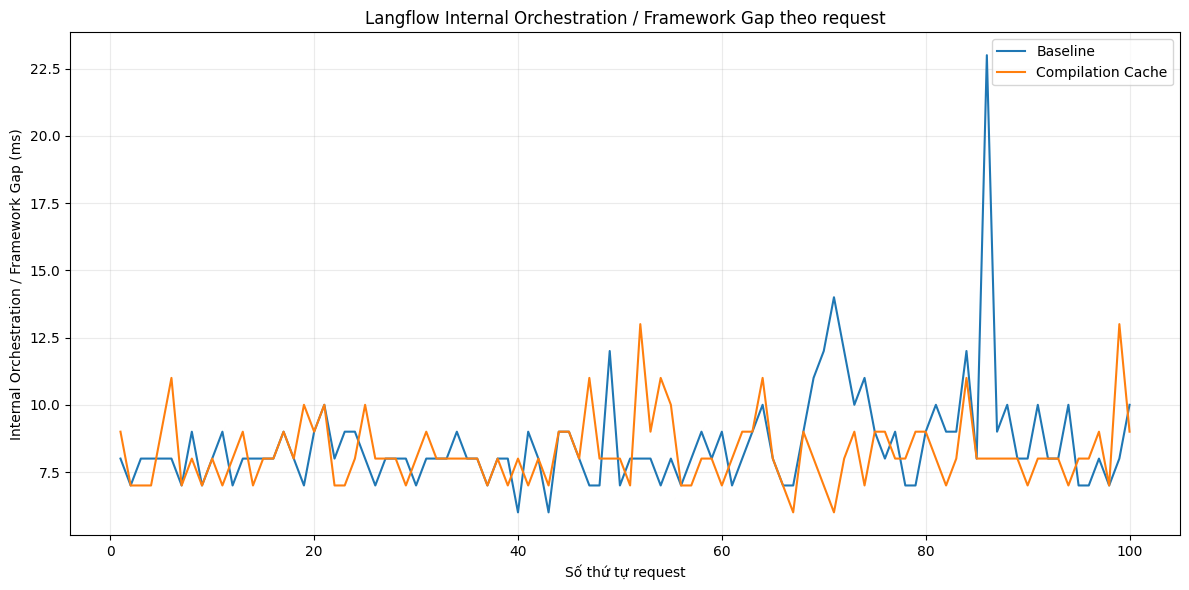

In [18]:
# Biểu đồ 6: orchestration/framework gap theo từng request
fig, axis = plt.subplots(figsize=(12, 6))
axis.plot(
    np.arange(1, len(baseline_runs) + 1),
    baseline_runs["langflow_orchestration_overhead_ms"],
    label="Baseline",
)
axis.plot(
    np.arange(1, len(cache_runs) + 1),
    cache_runs["langflow_orchestration_overhead_ms"],
    label="Compilation Cache",
)
axis.set_xlabel("Số thứ tự request")
axis.set_ylabel("Internal Orchestration / Framework Gap (ms)")
axis.set_title("Langflow Internal Orchestration / Framework Gap theo request")
axis.legend()
axis.grid(alpha=0.25)
fig.tight_layout()
generated_figures.append(fig)
orchestration_line_figure = fig
plt.show()

## 11. Phân phối và boxplot

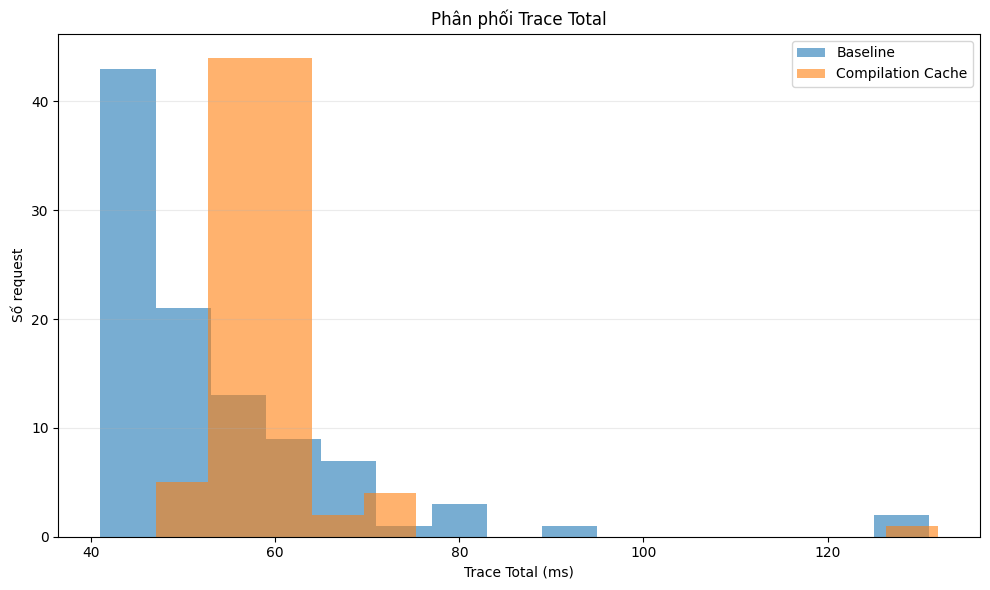

In [19]:
# Biểu đồ 7: phân phối Trace Total
fig, axis = plt.subplots(figsize=(10, 6))
axis.hist(baseline_runs["trace_total_latency_ms"].dropna(), bins=15, alpha=0.60, label="Baseline")
axis.hist(cache_runs["trace_total_latency_ms"].dropna(), bins=15, alpha=0.60, label="Compilation Cache")
axis.set_xlabel("Trace Total (ms)")
axis.set_ylabel("Số request")
axis.set_title("Phân phối Trace Total")
axis.legend()
axis.grid(axis="y", alpha=0.25)
fig.tight_layout()
generated_figures.append(fig)
trace_histogram_figure = fig
plt.show()

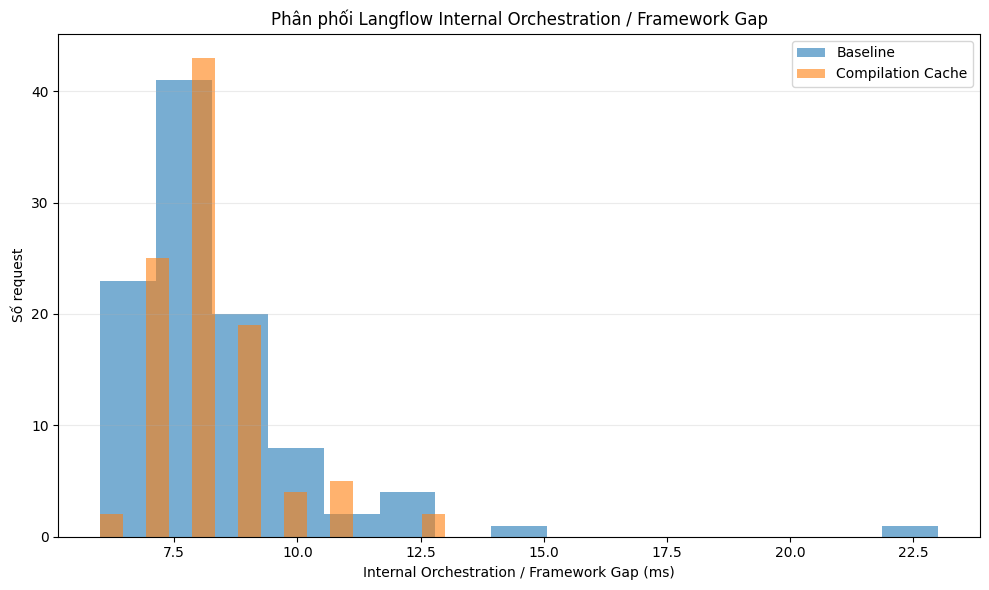

In [20]:
# Biểu đồ 8: phân phối orchestration/framework gap
fig, axis = plt.subplots(figsize=(10, 6))
axis.hist(
    baseline_runs["langflow_orchestration_overhead_ms"].dropna(),
    bins=15,
    alpha=0.60,
    label="Baseline",
)
axis.hist(
    cache_runs["langflow_orchestration_overhead_ms"].dropna(),
    bins=15,
    alpha=0.60,
    label="Compilation Cache",
)
axis.set_xlabel("Internal Orchestration / Framework Gap (ms)")
axis.set_ylabel("Số request")
axis.set_title("Phân phối Langflow Internal Orchestration / Framework Gap")
axis.legend()
axis.grid(axis="y", alpha=0.25)
fig.tight_layout()
generated_figures.append(fig)
orchestration_histogram_figure = fig
plt.show()

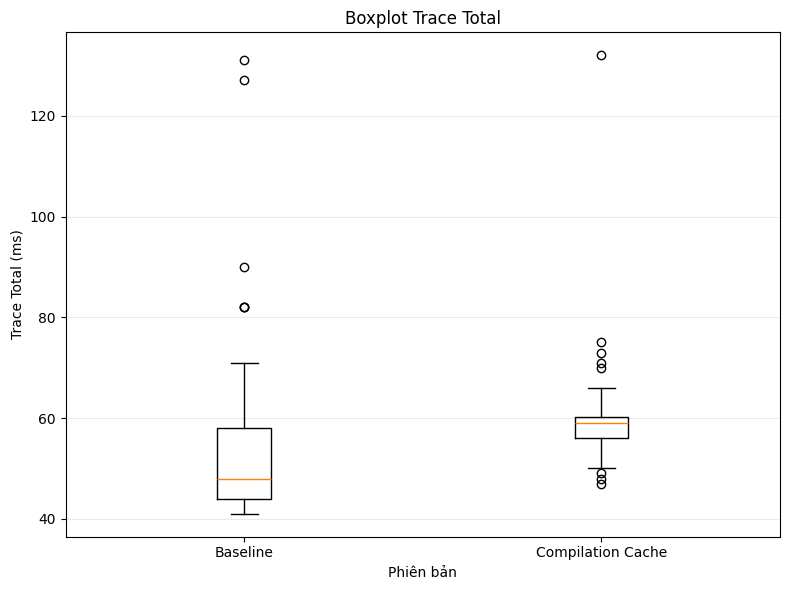

In [21]:
# Biểu đồ 9a: boxplot Trace Total
fig, axis = plt.subplots(figsize=(8, 6))
axis.boxplot(
    [
        baseline_runs["trace_total_latency_ms"].dropna(),
        cache_runs["trace_total_latency_ms"].dropna(),
    ],
    tick_labels=["Baseline", "Compilation Cache"],
)
axis.set_ylabel("Trace Total (ms)")
axis.set_xlabel("Phiên bản")
axis.set_title("Boxplot Trace Total")
axis.grid(axis="y", alpha=0.25)
fig.tight_layout()
generated_figures.append(fig)
trace_boxplot_figure = fig
plt.show()

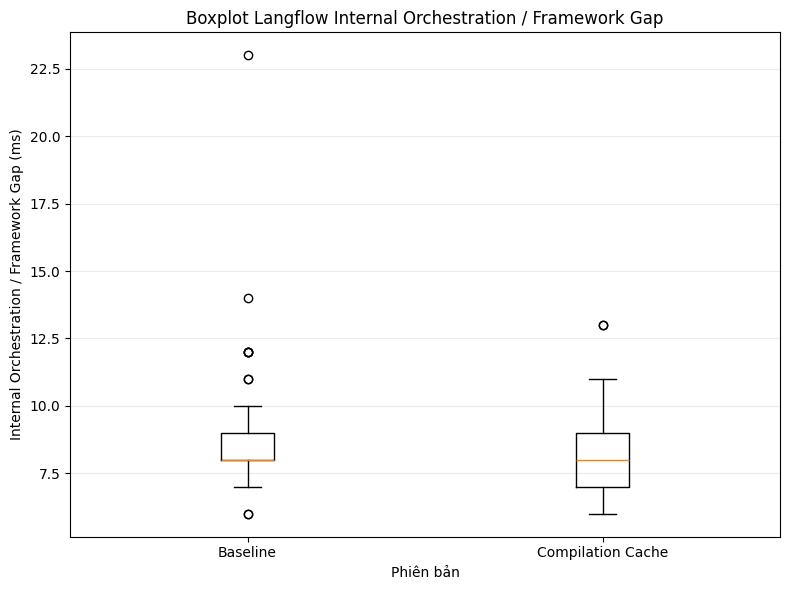

In [22]:
# Biểu đồ 9b: boxplot orchestration/framework gap
fig, axis = plt.subplots(figsize=(8, 6))
axis.boxplot(
    [
        baseline_runs["langflow_orchestration_overhead_ms"].dropna(),
        cache_runs["langflow_orchestration_overhead_ms"].dropna(),
    ],
    tick_labels=["Baseline", "Compilation Cache"],
)
axis.set_ylabel("Internal Orchestration / Framework Gap (ms)")
axis.set_xlabel("Phiên bản")
axis.set_title("Boxplot Langflow Internal Orchestration / Framework Gap")
axis.grid(axis="y", alpha=0.25)
fig.tight_layout()
generated_figures.append(fig)
orchestration_boxplot_figure = fig
plt.show()

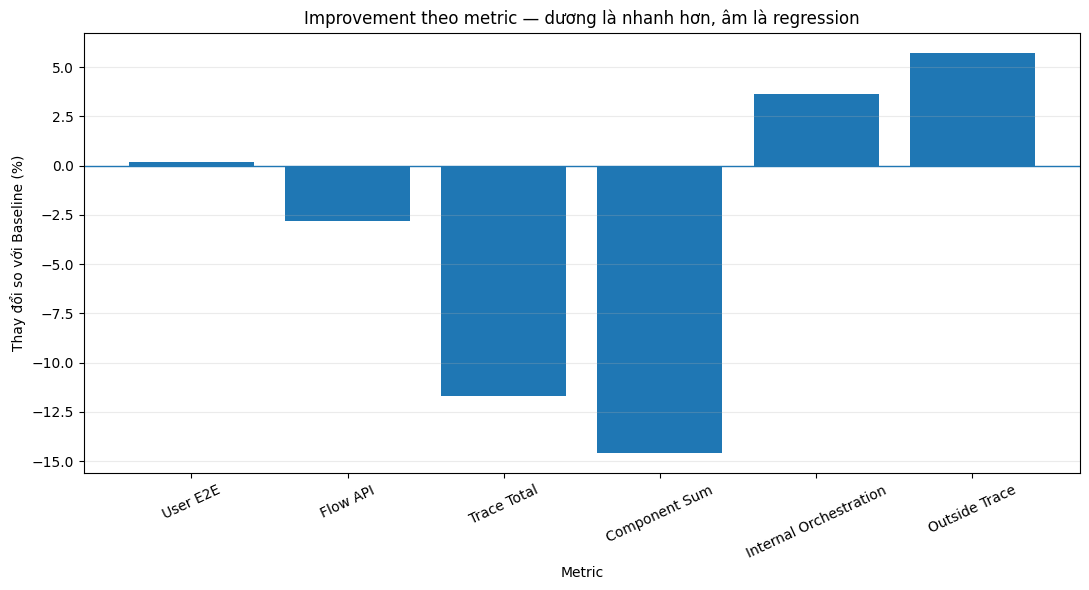

In [23]:
# Biểu đồ 10: tỷ lệ nhanh hơn hoặc regression theo metric
improvement_plot = core_summary.set_index("Metric").loc[PLOT_METRICS, "Improvement %"]
fig, axis = plt.subplots(figsize=(11, 6))
axis.bar(improvement_plot.index, improvement_plot.values)
axis.axhline(0, linewidth=1)
axis.set_xlabel("Metric")
axis.set_ylabel("Thay đổi so với Baseline (%)")
axis.set_title("Improvement theo metric — dương là nhanh hơn, âm là regression")
axis.tick_params(axis="x", rotation=25)
axis.grid(axis="y", alpha=0.25)
fig.tight_layout()
generated_figures.append(fig)
improvement_figure = fig
plt.show()

## 12. Phân tích outlier

Outlier được xác định riêng cho từng phiên bản và metric bằng quy tắc IQR 1,5 lần. Outlier **không bị xóa khỏi kết quả chính**.

In [24]:
OUTLIER_METRICS = {
    "Trace Total": "trace_total_latency_ms",
    "Internal Orchestration": "langflow_orchestration_overhead_ms",
    "User E2E": "user_e2e_latency_ms",
}


def iqr_outlier_mask(series):
    '''Trả mask outlier cùng hai ngưỡng IQR.'''
    values = pd.to_numeric(series, errors="coerce")
    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return values.lt(lower) | values.gt(upper), lower, upper


outlier_rows = []
for version, dataframe in {
    "Baseline": baseline_runs,
    "Compilation Cache": cache_runs,
}.items():
    for label, column in OUTLIER_METRICS.items():
        mask, lower, upper = iqr_outlier_mask(dataframe[column])
        outlier_rows.append(
            {
                "Version": version,
                "Metric": label,
                "Ngưỡng dưới": lower,
                "Ngưỡng trên": upper,
                "Số outlier": int(mask.sum()),
            }
        )

outlier_summary = pd.DataFrame(outlier_rows)
display(outlier_summary.style.format(precision=2))

,Version,Metric,Ngưỡng dưới,Ngưỡng trên,Số outlier
0,Baseline,Trace Total,23.00,79.00,6
1,Baseline,Internal Orchestration,6.50,10.50,10
2,Baseline,User E2E,67.50,156.58,6
3,Compilation Cache,Trace Total,49.62,66.62,8
4,Compilation Cache,Internal Orchestration,4.00,12.00,2
5,Compilation Cache,User E2E,101.84,122.75,9


In [25]:
def select_slowest(dataframe, version):
    '''Chuẩn hóa cột dùng trong bảng các request chậm nhất.'''
    selected = dataframe[
        [
            "run",
            "user_e2e_latency_ms",
            "flow_api_latency_ms",
            "trace_total_latency_ms",
            "component_sum_ms",
            "langflow_orchestration_overhead_ms",
        ]
    ].copy()
    selected.insert(0, "Version", version)
    return selected.rename(
        columns={
            "run": "Run",
            "user_e2e_latency_ms": "User E2E",
            "flow_api_latency_ms": "Flow API",
            "trace_total_latency_ms": "Trace",
            "component_sum_ms": "Component Sum",
            "langflow_orchestration_overhead_ms": "Orchestration",
        }
    )


top_slowest = (
    pd.concat(
        [
            select_slowest(baseline_runs, "Baseline"),
            select_slowest(cache_runs, "Compilation Cache"),
        ],
        ignore_index=True,
    )
    .sort_values("User E2E", ascending=False)
    .head(10)
    .reset_index(drop=True)
)
display(top_slowest.style.format(precision=2))

,Version,Run,User E2E,Flow API,Trace,Component Sum,Orchestration
0,Baseline,56,518.32,506.19,47.00,40.00,7.00
1,Compilation Cache,67,423.01,413.53,48.00,42.00,6.00
2,Compilation Cache,4,417.93,409.54,53.00,46.00,7.00
3,Baseline,92,235.87,178.80,54.00,46.00,8.00
4,Baseline,94,224.59,195.25,131.00,121.00,10.00
5,Baseline,72,205.86,184.37,90.00,78.00,12.00
6,Baseline,86,199.17,189.04,127.00,104.00,23.00
7,Compilation Cache,11,184.98,174.83,132.00,125.00,7.00
8,Baseline,69,171.07,159.20,82.00,71.00,11.00
9,Compilation Cache,33,167.48,158.95,47.00,39.00,8.00


## 13. Phân tích độ ổn định

Standard deviation, coefficient of variation (`CV = std / mean`), max, P95 và số outlier cho biết cache chỉ thay đổi tốc độ hay còn thay đổi độ ổn định của runtime.

In [26]:
def outlier_count(series):
    '''Đếm outlier theo IQR cho một chuỗi.'''
    mask, _, _ = iqr_outlier_mask(series)
    return int(mask.sum())


stability_rows = []
for label, column in CORE_METRICS.items():
    baseline_values = baseline_runs[column].dropna()
    cache_values = cache_runs[column].dropna()
    baseline_mean = baseline_values.mean()
    cache_mean = cache_values.mean()
    stability_rows.append(
        {
            "Metric": label,
            "Baseline Std": baseline_values.std(ddof=1),
            "Cache Std": cache_values.std(ddof=1),
            "Baseline CV": baseline_values.std(ddof=1) / baseline_mean if baseline_mean else np.nan,
            "Cache CV": cache_values.std(ddof=1) / cache_mean if cache_mean else np.nan,
            "Baseline Max": baseline_values.max(),
            "Cache Max": cache_values.max(),
            "Baseline P95": baseline_values.quantile(0.95),
            "Cache P95": cache_values.quantile(0.95),
            "Baseline Outliers": outlier_count(baseline_values),
            "Cache Outliers": outlier_count(cache_values),
        }
    )

stability_table = pd.DataFrame(stability_rows)
display(stability_table.style.format(precision=3, na_rep="Không đủ dữ liệu"))

,Metric,Baseline Std,Cache Std,Baseline CV,Cache CV,Baseline Max,Cache Max,Baseline P95,Cache P95,Baseline Outliers,Cache Outliers
0,Upload,6.438,0.732,0.527,0.081,56.923,12.666,22.886,10.330,8,6
1,Flow API,45.954,44.401,0.425,0.399,506.186,413.526,160.176,119.904,8,10
2,User E2E,47.631,44.386,0.395,0.369,518.317,423.010,172.474,128.753,6,9
3,Trace Total,15.020,8.548,0.283,0.144,131.000,132.000,82.000,66.200,6,8
4,Component Sum,13.753,8.676,0.309,0.170,121.000,125.000,68.150,57.250,6,9
5,Internal Orchestration,1.997,1.262,0.234,0.153,23.000,13.000,12.000,11.000,10,2
6,Outside Trace,42.412,45.085,0.769,0.867,459.186,365.526,72.515,55.865,10,11


## 14. Kiểm định thống kê

Mann–Whitney U hai phía được dùng khi mỗi nhóm có ít nhất 20 giá trị hợp lệ. P-value được đọc cùng effect size theo ms, phần trăm thay đổi, P50, P95 và hình dạng distribution; không kết luận chỉ dựa trên p-value.

In [27]:
SIGNIFICANCE_METRICS = {
    "Trace Total": "trace_total_latency_ms",
    "Component Sum": "component_sum_ms",
    "Internal Orchestration": "langflow_orchestration_overhead_ms",
    "Flow API": "flow_api_latency_ms",
    "User E2E": "user_e2e_latency_ms",
}


significance_rows = []
for label, column in SIGNIFICANCE_METRICS.items():
    baseline_values = baseline_runs[column].dropna()
    cache_values = cache_runs[column].dropna()
    baseline_median = baseline_values.median()
    cache_median = cache_values.median()
    p_value = np.nan
    if len(baseline_values) >= 20 and len(cache_values) >= 20:
        _, p_value = mannwhitneyu(
            baseline_values,
            cache_values,
            alternative="two-sided",
            method="auto",
        )
    significance_rows.append(
        {
            "Metric": label,
            "Baseline Median": baseline_median,
            "Cache Median": cache_median,
            "Delta ms": baseline_median - cache_median,
            "% Change": safe_improvement(baseline_median, cache_median),
            "p-value": p_value,
            "Baseline n": len(baseline_values),
            "Cache n": len(cache_values),
        }
    )

significance_table = pd.DataFrame(significance_rows)
display(significance_table.style.format(precision=4, na_rep="Không đủ dữ liệu"))

,Metric,Baseline Median,Cache Median,Delta ms,% Change,p-value,Baseline n,Cache n
0,Trace Total,48.0000,59.0000,-11.0000,-22.9167,0.0000,100,100
1,Component Sum,40.0000,50.0000,-10.0000,-25.0000,0.0000,100,100
2,Internal Orchestration,8.0000,8.0000,0.0000,0.0000,0.3100,100,100
3,Flow API,96.5807,103.1119,-6.5311,-6.7624,0.0021,100,100
4,User E2E,108.9995,112.7829,-3.7833,-3.4710,0.0653,100,100


## 15. Cold và warm: kiểm tra ổn định phụ

Dataset đã bỏ 5 warm-up request, vì vậy không đủ để kết luận cold-start. So sánh 10 request đo đầu với các request còn lại chỉ là kiểm tra drift/stabilization phụ; không được suy luận cache hit/miss khi CSV không có trường đó.

In [28]:
drift_rows = []
for version, dataframe in {
    "Baseline": baseline_runs,
    "Compilation Cache": cache_runs,
}.items():
    for label, column in {
        "Trace Total": "trace_total_latency_ms",
        "Internal Orchestration": "langflow_orchestration_overhead_ms",
        "User E2E": "user_e2e_latency_ms",
    }.items():
        first_values = dataframe[column].iloc[:10].dropna()
        later_values = dataframe[column].iloc[10:].dropna()
        first_mean = first_values.mean()
        later_mean = later_values.mean()
        drift_rows.append(
            {
                "Version": version,
                "Metric": label,
                "Mean 10 request đầu": first_mean,
                "Mean các request sau": later_mean,
                "Chênh lệch đầu - sau (ms)": first_mean - later_mean,
            }
        )

warm_drift_table = pd.DataFrame(drift_rows)
display(warm_drift_table.style.format(precision=2, na_rep="Không đủ dữ liệu"))

,Version,Metric,Mean 10 request đầu,Mean các request sau,Chênh lệch đầu - sau (ms)
0,Baseline,Trace Total,44.50,53.99,-9.49
1,Baseline,Internal Orchestration,7.80,8.62,-0.82
2,Baseline,User E2E,106.00,122.17,-16.17
3,Compilation Cache,Trace Total,58.50,59.31,-0.81
4,Compilation Cache,Internal Orchestration,8.00,8.26,-0.26
5,Compilation Cache,User E2E,142.49,117.85,24.63


## 16. Phân tích tác động của cache

Phần này trả lời trực tiếp các câu hỏi về Trace Total, Component Sum, Internal Orchestration, SCRFD Inference, Flow API, User E2E, Outside Trace, P95 và variance. Nội dung được sinh từ các bảng đã tính ở trên.

In [29]:
def direction_text(value, tolerance=0.05):
    '''Mô tả dấu của improvement mà không gọi regression là cải thiện.'''
    if pd.isna(value):
        return "chưa đủ dữ liệu"
    if value > tolerance:
        return f"nhanh hơn {value:.2f}%"
    if value < -tolerance:
        return f"regression {abs(value):.2f}%"
    return f"gần như không đổi ({value:.2f}%)"


core_indexed = core_summary.set_index("Metric")
stability_indexed = stability_table.set_index("Metric")
inference_row = component_comparison.set_index("Component").loc["SCRFD Inference"]

cache_effect_answers = pd.DataFrame(
    [
        {
            "Câu hỏi": "1. Trace Total có giảm không?",
            "Trả lời theo dữ liệu": direction_text(core_indexed.loc["Trace Total", "Improvement %"]),
        },
        {
            "Câu hỏi": "2. Component Sum có giảm không?",
            "Trả lời theo dữ liệu": direction_text(core_indexed.loc["Component Sum", "Improvement %"]),
        },
        {
            "Câu hỏi": "3. Internal Orchestration Gap có giảm không?",
            "Trả lời theo dữ liệu": direction_text(core_indexed.loc["Internal Orchestration", "Improvement %"]),
        },
        {
            "Câu hỏi": "4. SCRFD Inference có thay đổi đáng kể không?",
            "Trả lời theo dữ liệu": direction_text(inference_row["Improvement %"], NEGLIGIBLE_CHANGE_PCT),
        },
        {
            "Câu hỏi": "5. Flow API có được hưởng lợi không?",
            "Trả lời theo dữ liệu": direction_text(core_indexed.loc["Flow API", "Improvement %"]),
        },
        {
            "Câu hỏi": "6. User E2E có được hưởng lợi không?",
            "Trả lời theo dữ liệu": direction_text(core_indexed.loc["User E2E", "Improvement %"]),
        },
        {
            "Câu hỏi": "7. Outside Trace Gap thay đổi thế nào?",
            "Trả lời theo dữ liệu": direction_text(core_indexed.loc["Outside Trace", "Improvement %"]),
        },
        {
            "Câu hỏi": "8. P95 Trace Total có giảm không?",
            "Trả lời theo dữ liệu": direction_text(
                safe_improvement(
                    core_indexed.loc["Trace Total", "Baseline P95"],
                    core_indexed.loc["Trace Total", "Cache P95"],
                )
            ),
        },
        {
            "Câu hỏi": "9. Standard deviation Trace Total có giảm không?",
            "Trả lời theo dữ liệu": direction_text(
                safe_improvement(
                    stability_indexed.loc["Trace Total", "Baseline Std"],
                    stability_indexed.loc["Trace Total", "Cache Std"],
                )
            ),
        },
        {
            "Câu hỏi": "10. Cache có làm Trace Total ổn định hơn không?",
            "Trả lời theo dữ liệu": direction_text(
                safe_improvement(
                    stability_indexed.loc["Trace Total", "Baseline CV"],
                    stability_indexed.loc["Trace Total", "Cache CV"],
                )
            ),
        },
    ]
)
display(cache_effect_answers)

,Câu hỏi,Trả lời theo dữ liệu
0,1. Trace Total có giảm không?,regression 11.67%
1,2. Component Sum có giảm không?,regression 14.61%
2,3. Internal Orchestration Gap có giảm không?,nhanh hơn 3.63%
3,4. SCRFD Inference có thay đổi đáng kể không?,regression 24.20%
4,5. Flow API có được hưởng lợi không?,regression 2.81%
5,6. User E2E có được hưởng lợi không?,nhanh hơn 0.20%
6,7. Outside Trace Gap thay đổi thế nào?,nhanh hơn 5.72%
7,8. P95 Trace Total có giảm không?,nhanh hơn 19.27%
8,9. Standard deviation Trace Total có giảm không?,nhanh hơn 43.09%
9,10. Cache có làm Trace Total ổn định hơn không?,nhanh hơn 49.04%


## 17. Phân rã đóng góp latency

Phân rã dùng mean của `Upload`, `Outside Trace`, `Component Sum` và `Internal Orchestration`, rồi tính tỷ lệ trên User E2E mean. Sai số nhỏ còn lại có thể đến từ khoảng thời gian giữa upload và flow/API hoặc độ phân giải trace.

```text
User E2E
├── Upload
└── Flow API
    ├── Outside Trace Gap
    └── Trace Total
        ├── Component Sum
        └── Internal Orchestration
```

In [30]:
def build_contribution_rows(dataframe, version):
    '''Tính đóng góp mean của các tầng latency trên User E2E.'''
    user_e2e_mean = dataframe["user_e2e_latency_ms"].mean()
    parts = {
        "Upload": dataframe["upload_latency_ms"].mean(),
        "Outside Trace": dataframe["outside_trace_gap_ms"].mean(),
        "Component Sum": dataframe["component_sum_ms"].mean(),
        "Internal Orchestration": dataframe["langflow_orchestration_overhead_ms"].mean(),
    }
    return [
        {
            "Version": version,
            "Thành phần": label,
            "Mean ms": value,
            "% User E2E": value / user_e2e_mean * 100 if user_e2e_mean else np.nan,
        }
        for label, value in parts.items()
    ]


contribution_table = pd.DataFrame(
    build_contribution_rows(baseline_runs, "Baseline")
    + build_contribution_rows(cache_runs, "Compilation Cache")
)
display(contribution_table.style.format({"Mean ms": "{:.2f}", "% User E2E": "{:.2f}%"}))

,Version,Thành phần,Mean ms,% User E2E
0,Baseline,Upload,12.22,10.14%
1,Baseline,Outside Trace,55.13,45.73%
2,Baseline,Component Sum,44.50,36.91%
3,Baseline,Internal Orchestration,8.54,7.08%
4,Compilation Cache,Upload,9.03,7.50%
5,Compilation Cache,Outside Trace,51.98,43.20%
6,Compilation Cache,Component Sum,51.00,42.39%
7,Compilation Cache,Internal Orchestration,8.23,6.84%


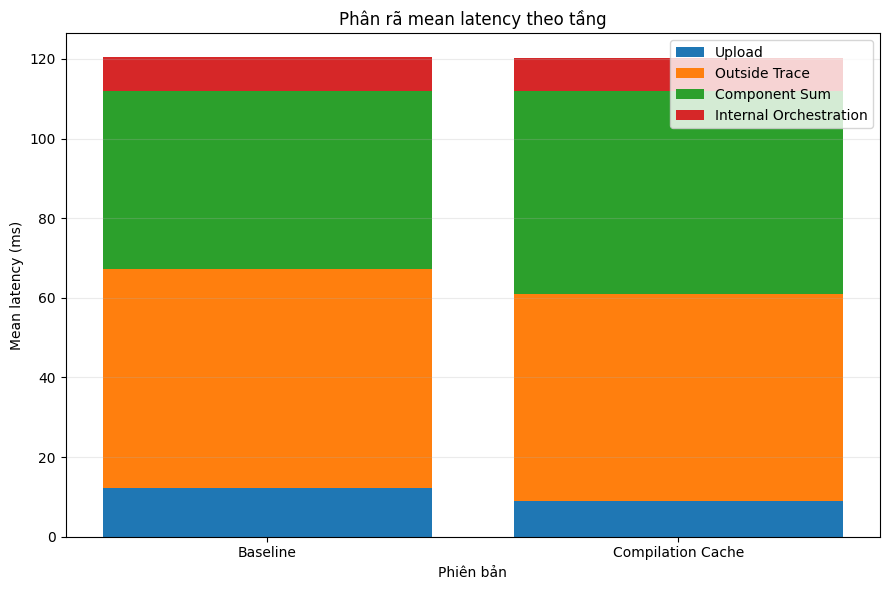

In [31]:
# Biểu đồ phân rã: mỗi cột là tổng các tầng latency được đo
contribution_pivot = contribution_table.pivot(
    index="Version", columns="Thành phần", values="Mean ms"
)
contribution_order = ["Upload", "Outside Trace", "Component Sum", "Internal Orchestration"]
contribution_pivot = contribution_pivot[contribution_order]

fig, axis = plt.subplots(figsize=(9, 6))
bottom = np.zeros(len(contribution_pivot))
for component in contribution_order:
    values = contribution_pivot[component].to_numpy()
    axis.bar(contribution_pivot.index, values, bottom=bottom, label=component)
    bottom += values
axis.set_xlabel("Phiên bản")
axis.set_ylabel("Mean latency (ms)")
axis.set_title("Phân rã mean latency theo tầng")
axis.legend()
axis.grid(axis="y", alpha=0.25)
fig.tight_layout()
generated_figures.append(fig)
contribution_figure = fig
plt.show()

## 18. Dashboard so sánh cuối cùng

In [32]:
dashboard_spec = [
    ("User E2E Mean", "User E2E", "Baseline Mean", "Cache Mean"),
    ("Flow API Mean", "Flow API", "Baseline Mean", "Cache Mean"),
    ("Trace Mean", "Trace Total", "Baseline Mean", "Cache Mean"),
    ("Component Sum Mean", "Component Sum", "Baseline Mean", "Cache Mean"),
    ("Orchestration Mean", "Internal Orchestration", "Baseline Mean", "Cache Mean"),
    ("Trace P50", "Trace Total", "Baseline P50", "Cache P50"),
    ("Trace P95", "Trace Total", "Baseline P95", "Cache P95"),
    ("Orchestration P50", "Internal Orchestration", "Baseline P50", "Cache P50"),
    ("Orchestration P95", "Internal Orchestration", "Baseline P95", "Cache P95"),
    ("User E2E P50", "User E2E", "Baseline P50", "Cache P50"),
    ("User E2E P95", "User E2E", "Baseline P95", "Cache P95"),
]

dashboard_rows = []
for row_label, metric_label, baseline_column, cache_column in dashboard_spec:
    baseline_value = core_indexed.loc[metric_label, baseline_column]
    cache_value = core_indexed.loc[metric_label, cache_column]
    dashboard_rows.append(
        {
            "Metric": row_label,
            "Baseline": baseline_value,
            "Compilation Cache": cache_value,
            "Change ms": baseline_value - cache_value,
            "Change %": safe_improvement(baseline_value, cache_value),
        }
    )

final_dashboard = pd.DataFrame(dashboard_rows)
display(
    final_dashboard.style.format(
        {
            "Baseline": "{:.2f}",
            "Compilation Cache": "{:.2f}",
            "Change ms": "{:.2f}",
            "Change %": "{:.2f}%",
        }
    )
)

,Metric,Baseline,Compilation Cache,Change ms,Change %
0,User E2E Mean,120.56,120.32,0.24,0.20%
1,Flow API Mean,108.17,111.21,-3.04,-2.81%
2,Trace Mean,53.04,59.23,-6.19,-11.67%
3,Component Sum Mean,44.50,51.00,-6.50,-14.61%
4,Orchestration Mean,8.54,8.23,0.31,3.63%
5,Trace P50,48.00,59.00,-11.00,-22.92%
6,Trace P95,82.00,66.20,15.80,19.27%
7,Orchestration P50,8.00,8.00,0.00,0.00%
8,Orchestration P95,12.00,11.00,1.00,8.33%
9,User E2E P50,109.00,112.78,-3.78,-3.47%


## 19. Kết luận dựa trên dữ liệu

Kết luận dưới đây được tạo khi chạy notebook. Mọi con số lấy từ `core_summary`, `component_comparison`, `stability_table`, `significance_table` và `contribution_table`; không có kết quả benchmark nào được hard-code.

In [33]:
def metric_sentence(label):
    '''Sinh câu mô tả mean và P95 của một metric.'''
    row = core_indexed.loc[label]
    return (
        f"{label}: mean {row['Baseline Mean']:.2f} → {row['Cache Mean']:.2f} ms "
        f"({direction_text(row['Improvement %'])}); P95 "
        f"{row['Baseline P95']:.2f} → {row['Cache P95']:.2f} ms."
    )


cache_component = component_comparison.set_index("Component")
largest_component_change = cache_component["Improvement %"].abs().idxmax()
cache_contributions = contribution_table.loc[
    contribution_table["Version"].eq("Compilation Cache")
].set_index("Thành phần")
remaining_bottleneck = cache_contributions["Mean ms"].idxmax()

trace_improvement = core_indexed.loc["Trace Total", "Improvement %"]
component_improvement = core_indexed.loc["Component Sum", "Improvement %"]
orchestration_improvement = core_indexed.loc["Internal Orchestration", "Improvement %"]
user_improvement = core_indexed.loc["User E2E", "Improvement %"]
inference_improvement = cache_component.loc["SCRFD Inference", "Improvement %"]

if trace_improvement > 0 and (component_improvement > 0 or orchestration_improvement > 0):
    overall_verdict = "Dữ liệu phù hợp với việc cache cải thiện latency nội bộ của Langflow trong workload này."
elif trace_improvement <= 0:
    overall_verdict = "Dữ liệu không cho thấy Trace Total được cải thiện trong workload này; không nên khẳng định cache làm Langflow nhanh hơn tổng thể."
else:
    overall_verdict = "Trace Total giảm nhưng các tầng thành phần chưa cùng hướng; cần thêm benchmark lặp lại trước khi quy nguyên nhân cho cache."

if abs(inference_improvement) <= NEGLIGIBLE_CHANGE_PCT:
    inference_verdict = (
        "SCRFD Inference gần như không đổi, phù hợp với phạm vi optimization vì cache tác động vào "
        "LFX execution framework chứ không tác động vào ONNX model compute."
    )
else:
    inference_verdict = (
        f"SCRFD Inference {direction_text(inference_improvement)}. Vì cache không trực tiếp tối ưu ONNX compute, "
        "không thể tự động quy thay đổi này cho compilation cache."
    )

if abs(user_improvement) < abs(trace_improvement):
    user_context = (
        "Mức thay đổi ở User E2E nhỏ hơn thay đổi nội bộ; Upload và Outside Trace không phải target trực tiếp "
        "của cache nên có thể làm loãng hiệu ứng ở user level."
    )
else:
    user_context = (
        "Mức thay đổi User E2E không nhỏ hơn thay đổi Trace Total; cần đọc thêm Upload, Outside Trace và outlier "
        "trước khi quy toàn bộ khác biệt cho cache."
    )

data_driven_conclusion = "\n\n".join(
    [
        f"**A. Cache có cải thiện Langflow không?** {overall_verdict}",
        "**B. Thay đổi theo tầng.** " + metric_sentence("Trace Total") + " "
        + metric_sentence("Component Sum") + " " + metric_sentence("Internal Orchestration"),
        f"**C. SCRFD inference.** {inference_verdict}",
        f"**D. Trải nghiệm user.** {metric_sentence('Flow API')} {metric_sentence('User E2E')} {user_context}",
        f"**E. Tail latency và độ ổn định.** {metric_sentence('Trace Total')} "
        f"Trace Std {stability_indexed.loc['Trace Total', 'Baseline Std']:.2f} → "
        f"{stability_indexed.loc['Trace Total', 'Cache Std']:.2f} ms; số outlier "
        f"{stability_indexed.loc['Trace Total', 'Baseline Outliers']:.0f} → "
        f"{stability_indexed.loc['Trace Total', 'Cache Outliers']:.0f}.",
        f"**F. Bottleneck còn lại.** Trong bốn tầng được phân rã, phần lớn nhất sau cache là "
        f"{remaining_bottleneck} ({cache_contributions.loc[remaining_bottleneck, 'Mean ms']:.2f} ms mean). "
        f"Component có biến động tỷ lệ lớn nhất là {largest_component_change}; đây là mô tả, không tự nó chứng minh quan hệ nhân quả.",
    ]
)
display(Markdown(data_driven_conclusion))

**A. Cache có cải thiện Langflow không?** Dữ liệu không cho thấy Trace Total được cải thiện trong workload này; không nên khẳng định cache làm Langflow nhanh hơn tổng thể.

**B. Thay đổi theo tầng.** Trace Total: mean 53.04 → 59.23 ms (regression 11.67%); P95 82.00 → 66.20 ms. Component Sum: mean 44.50 → 51.00 ms (regression 14.61%); P95 68.15 → 57.25 ms. Internal Orchestration: mean 8.54 → 8.23 ms (nhanh hơn 3.63%); P95 12.00 → 11.00 ms.

**C. SCRFD inference.** SCRFD Inference regression 24.20%. Vì cache không trực tiếp tối ưu ONNX compute, không thể tự động quy thay đổi này cho compilation cache.

**D. Trải nghiệm user.** Flow API: mean 108.17 → 111.21 ms (regression 2.81%); P95 160.18 → 119.90 ms. User E2E: mean 120.56 → 120.32 ms (nhanh hơn 0.20%); P95 172.47 → 128.75 ms. Mức thay đổi ở User E2E nhỏ hơn thay đổi nội bộ; Upload và Outside Trace không phải target trực tiếp của cache nên có thể làm loãng hiệu ứng ở user level.

**E. Tail latency và độ ổn định.** Trace Total: mean 53.04 → 59.23 ms (regression 11.67%); P95 82.00 → 66.20 ms. Trace Std 15.02 → 8.55 ms; số outlier 6 → 8.

**F. Bottleneck còn lại.** Trong bốn tầng được phân rã, phần lớn nhất sau cache là Outside Trace (51.98 ms mean). Component có biến động tỷ lệ lớn nhất là Detection Image Output; đây là mô tả, không tự nó chứng minh quan hệ nhân quả.

## 20. Tóm tắt kỹ thuật cuối cùng

Đoạn 5–10 dòng dưới đây được format tự động từ DataFrame và có thể dùng trực tiếp trong báo cáo kỹ thuật.

In [34]:
trace_row = core_indexed.loc["Trace Total"]
orchestration_row = core_indexed.loc["Internal Orchestration"]
user_row = core_indexed.loc["User E2E"]
flow_row = core_indexed.loc["Flow API"]
inference_row = cache_component.loc["SCRFD Inference"]

final_technical_summary = "\n".join(
    [
        f"Trong workload warm / steady-state gồm {len(baseline_runs)} request Baseline và {len(cache_runs)} request Compilation Cache, kết quả được tính lại trực tiếp từ runs.csv.",
        f"Trace Total mean thay đổi từ {trace_row['Baseline Mean']:.2f} ms thành {trace_row['Cache Mean']:.2f} ms; {direction_text(trace_row['Improvement %'])}.",
        f"Internal orchestration/framework gap mean thay đổi từ {orchestration_row['Baseline Mean']:.2f} ms thành {orchestration_row['Cache Mean']:.2f} ms; {direction_text(orchestration_row['Improvement %'])}.",
        f"SCRFD inference mean thay đổi từ {inference_row['Baseline Mean']:.2f} ms thành {inference_row['Cache Mean']:.2f} ms; cache không trực tiếp tối ưu ONNX model compute.",
        f"Ở user level, Flow API mean thay đổi từ {flow_row['Baseline Mean']:.2f} ms thành {flow_row['Cache Mean']:.2f} ms và User E2E mean từ {user_row['Baseline Mean']:.2f} ms thành {user_row['Cache Mean']:.2f} ms.",
        f"Trace P95 thay đổi từ {trace_row['Baseline P95']:.2f} ms thành {trace_row['Cache P95']:.2f} ms; User E2E P95 từ {user_row['Baseline P95']:.2f} ms thành {user_row['Cache P95']:.2f} ms.",
        f"Sau cache, tầng đóng góp mean lớn nhất trong phân rã là {remaining_bottleneck}; kết quả không đại diện cho cold-start, concurrency hay maximum throughput.",
    ]
)
display(Markdown(final_technical_summary.replace("\n", "  \n")))

Trong workload warm / steady-state gồm 100 request Baseline và 100 request Compilation Cache, kết quả được tính lại trực tiếp từ runs.csv.  
Trace Total mean thay đổi từ 53.04 ms thành 59.23 ms; regression 11.67%.  
Internal orchestration/framework gap mean thay đổi từ 8.54 ms thành 8.23 ms; nhanh hơn 3.63%.  
SCRFD inference mean thay đổi từ 22.89 ms thành 28.43 ms; cache không trực tiếp tối ưu ONNX model compute.  
Ở user level, Flow API mean thay đổi từ 108.17 ms thành 111.21 ms và User E2E mean từ 120.56 ms thành 120.32 ms.  
Trace P95 thay đổi từ 82.00 ms thành 66.20 ms; User E2E P95 từ 172.47 ms thành 128.75 ms.  
Sau cache, tầng đóng góp mean lớn nhất trong phân rã là Outside Trace; kết quả không đại diện cho cold-start, concurrency hay maximum throughput.